### 0 Overview Visualizations

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
from io import BytesIO
import matplotlib as mpl
import matplotlib.cm as cm
import plotly.express as px

# Load the dataset
data = pd.read_csv('king_county_house_pandas_filled.csv')

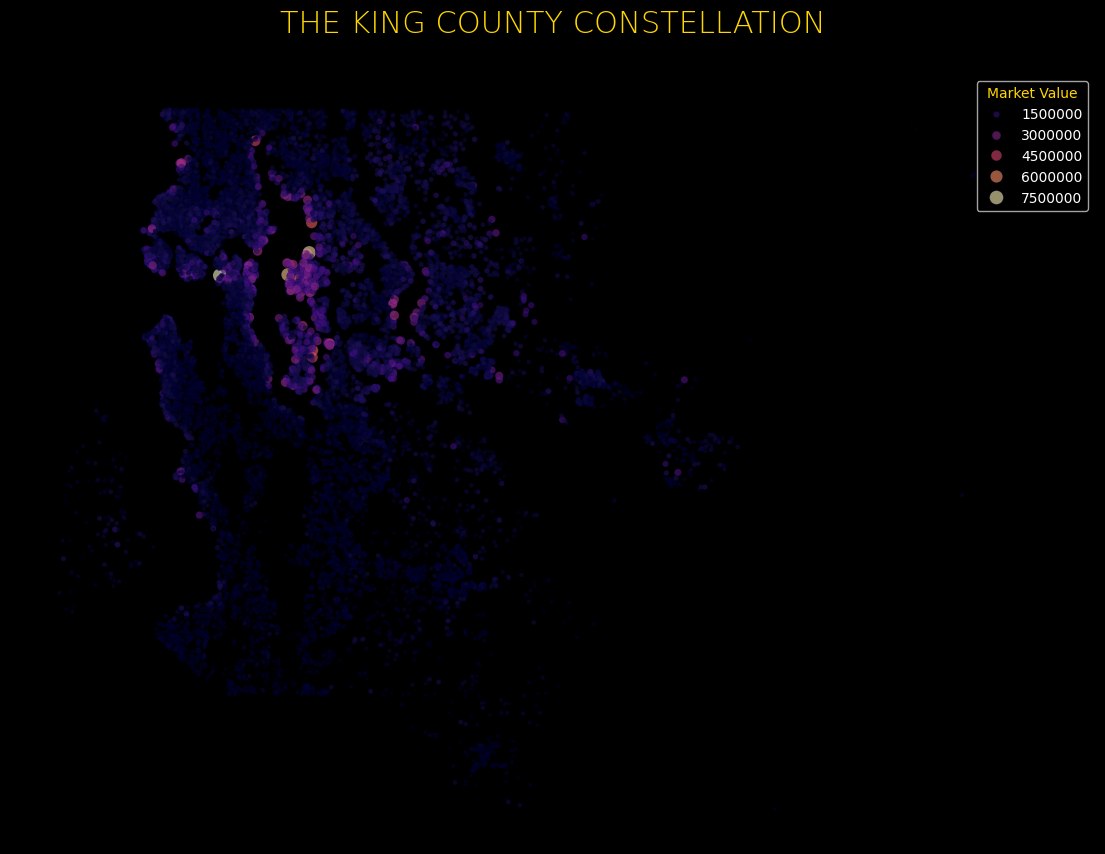

In [169]:


# 1. Dark Mode Theme
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 10))

# bg
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# 2. plotting
scatter = sns.scatterplot(data=data, x='long', y='lat', 
                          hue='price', palette='magma', 
                          size='price', sizes=(1, 100), 
                          alpha=0.6, edgecolor='darkblue', ax=ax)

# 3. title & labels
plt.title('THE KING COUNTY CONSTELLATION', 
          fontsize=22, color='gold', fontweight='light', pad=30)

# 4. remove scale and axes for a more "map-like" look
ax.set_xticks([]) # Entfernt X-Ticks
ax.set_yticks([]) # Entfernt Y-Ticks
ax.set_xlabel('') # Entfernt X-Label
ax.set_ylabel('') # Entfernt Y-Label

# remove spines for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# 5. legend
legend = ax.legend(title='Market Value', loc='upper right', 
                   frameon=True, labelcolor='white')
plt.setp(legend.get_title(), color='gold')

plt.show()

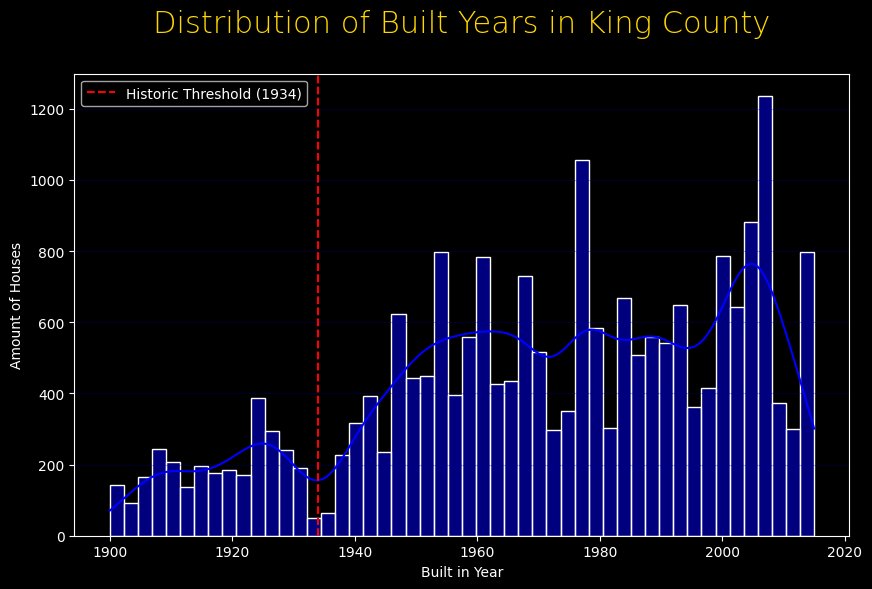

In [170]:
plt.figure(figsize=(10, 6))
plt.style.use('dark_background')

sns.histplot(data['yr_built'], bins=50, color='blue', kde=True)

# historical threshold for original houses (before 1934)
plt.axvline(1934, color='red', linestyle='--', label='Historic Threshold (1934)')

plt.title('Distribution of Built Years in King County', 
          fontsize=22, color='gold', fontweight='light', pad=30)
plt.xlabel('Built in Year')
plt.ylabel('Amount of Houses')
plt.legend()
plt.grid(axis='y', alpha=0.3, color='darkblue')
plt.show()

---------------------------------------------------------------------------------------------

### 1 Hypothesis
-	map lat/long, size points= size of sqft_lot
-   House in lat/long that have a lot of space for pool&golf&tennis_court but with no waterfront

In [171]:
# --- Filter ---
# 1. no waterfront
# 2. large lot (Top 5% der sqft_lot) -> enough space for pool/tennis/golf 

lot_threshold = data['sqft_lot'].quantile(0.95) #

jacob_h1 = data[
    (data['waterfront'] == 0) & 
    (data['sqft_lot'] >= lot_threshold)
].copy()

print(f"found houses for hypothesis 1: {len(jacob_h1)}")

found houses for hypothesis 1: 1061


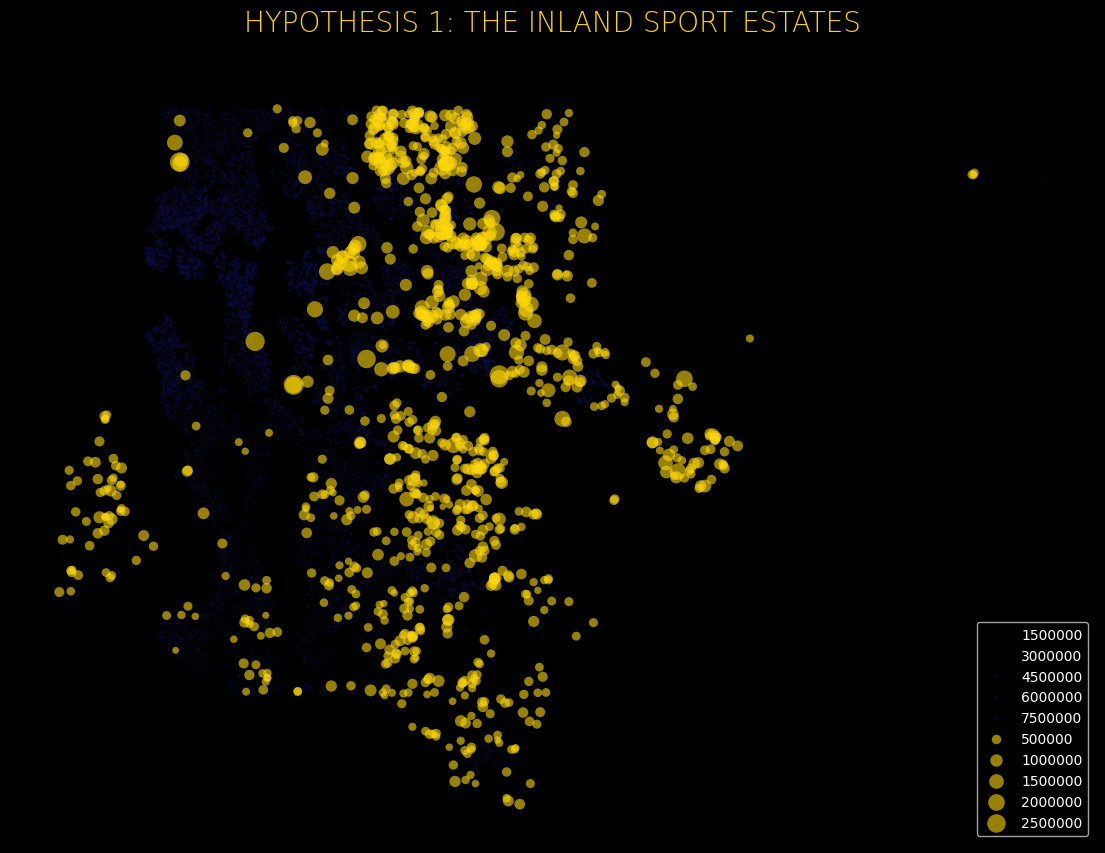

In [172]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Background: All Houses in darkgrey
sns.scatterplot(data=data, x='long', y='lat', color="#0F0E4D", 
                size='price', sizes=(1, 20), alpha=0.3, edgecolor='none', ax=ax)

# Highlight: Filter (in Gold)
sns.scatterplot(data=jacob_h1, x='long', y='lat', color='#FFD700', 
                size='price', sizes=(20, 200), alpha=0.6, edgecolor='white', linewidth=0.1, 
                ax=ax)

# Branding & Clean-up
plt.title('HYPOTHESIS 1: THE INLAND SPORT ESTATES', 
          fontsize=20, color='gold', fontweight='light', pad=30)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(False)

# legend
legend = ax.legend(frameon=True, loc='lower right', labelcolor='white')
plt.setp(legend.get_title(), color='gold')

plt.show()

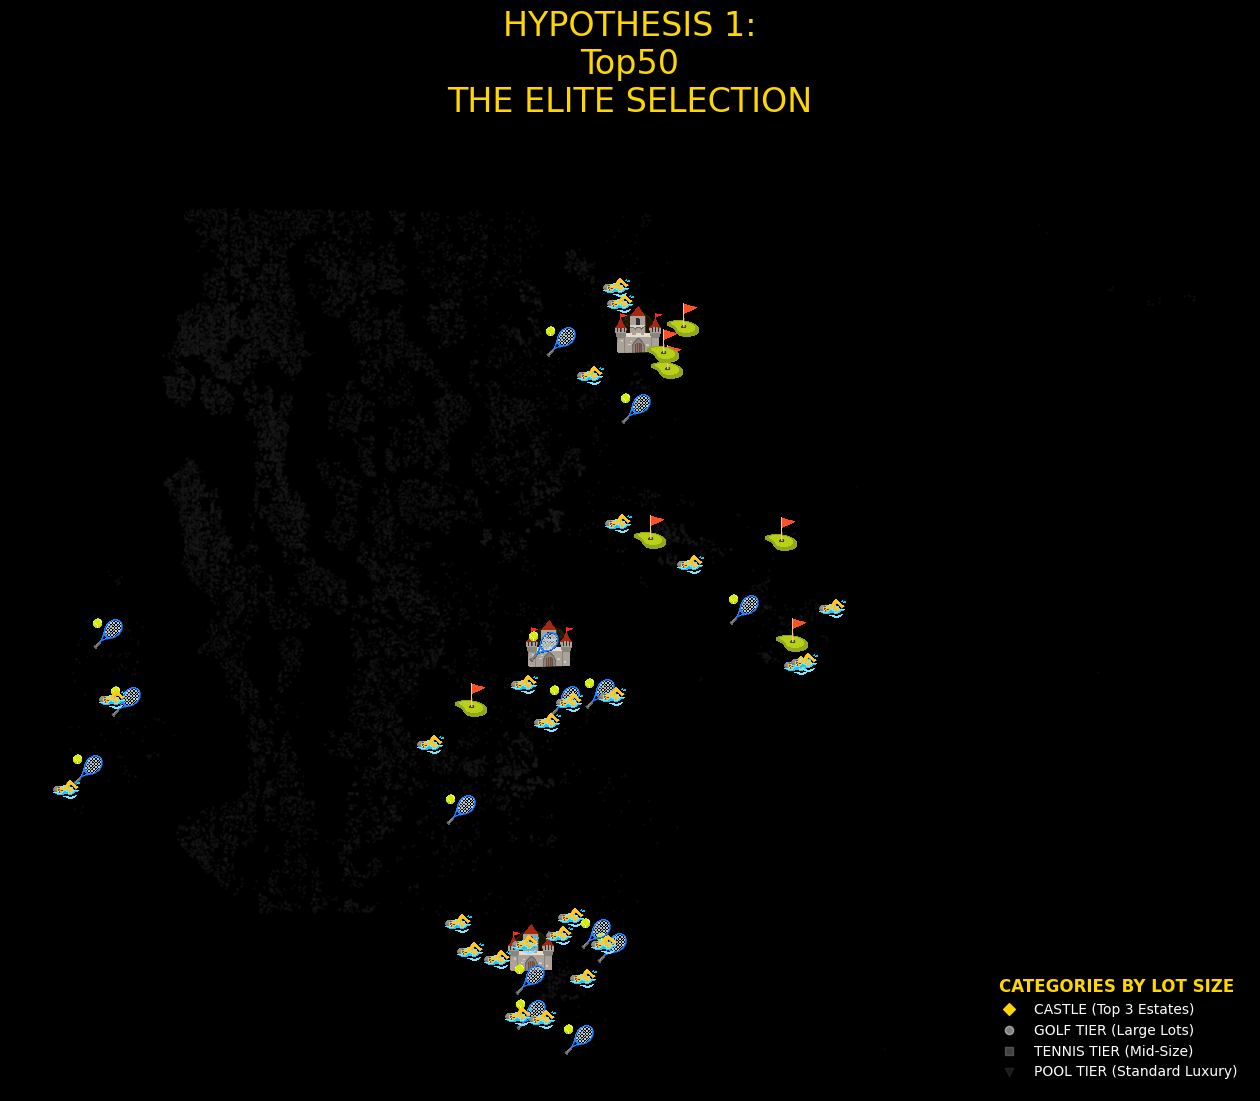

In [173]:
# --- 1. setup ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Background
ax.scatter(data['long'], data['lat'], s=1, color='#1a1a1a', alpha=0.3)

# --- 2. icon links ---
castle_url = "https://fonts.gstatic.com/s/e/notoemoji/latest/1f3f0/512.png" 
golf_url   = "https://fonts.gstatic.com/s/e/notoemoji/latest/26f3/512.png"   
tennis_url = "https://fonts.gstatic.com/s/e/notoemoji/latest/1f3be/512.png" 
pool_url   = "https://fonts.gstatic.com/s/e/notoemoji/latest/1f3ca_200d_2642_fe0f/512.png"

def add_icon(x, y, icon_url, ax, zoom):
    try:
        response = requests.get(icon_url)
        img = plt.imread(BytesIO(response.content), format='png')
        imagebox = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
    except: pass

# --- 3. sort and plot ---
sample_estates = jacob_h1.sort_values(by='sqft_lot', ascending=False).head(50).copy()

for i, (idx, row) in enumerate(sample_estates.reset_index().iterrows()):
    if i < 3:
        url, zoom = castle_url, 0.07
        ax.scatter(row['long'], row['lat'], s=600, color='gold', alpha=0.1) # Glow für Schlösser
    elif i < 10:
        url, zoom = golf_url, 0.05
    elif i < 25:
        url, zoom = tennis_url, 0.045
    else:
        url, zoom = pool_url, 0.04
    
    add_icon(row['long'], row['lat'], url, ax, zoom)

# --- 4. legend
ax.scatter([], [], color='gold', label='CASTLE (Top 3 Estates)', marker='D')
ax.scatter([], [], color='white', label='GOLF TIER (Large Lots)', marker='o', alpha=0.5)
ax.scatter([], [], color='gray', label='TENNIS TIER (Mid-Size)', marker='s', alpha=0.5)
ax.scatter([], [], color='#333333', label='POOL TIER (Standard Luxury)', marker='v', alpha=0.5)

# show legend
leg = ax.legend(loc='lower right', frameon=False, fontsize=10, labelcolor='white')
leg.set_title("CATEGORIES BY LOT SIZE", prop={'size': 12, 'weight': 'bold'})
plt.setp(leg.get_title(), color='gold')

# --- 6. finishing ---
plt.title('HYPOTHESIS 1:\nTop50\nTHE ELITE SELECTION', fontsize=24, color='gold', pad=40)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

In [174]:
# 1. sort values
jacob_results = jacob_h1.sort_values(by='sqft_lot', ascending=False).copy()

# 2. categorize
def assign_category(index):
    if index < 3: return '🏰 Elite Top3'
    elif index < 10: return '⛳ Golf Tier'
    elif index < 25: return '🎾 Tennis Tier'
    else: return '🏊‍♂️ Pool Tier'

# reset index to assign categories based on position
jacob_results = jacob_results.reset_index()
jacob_results['Category'] = jacob_results.index.map(assign_category)

# 3. aggregate stats
stats = jacob_results.groupby('Category')['sqft_lot'].agg(['count', 'min', 'max', 'mean']).round(0)

# sort order
category_order = ['🏰 Elite Top3', '⛳ Golf Tier', '🎾 Tennis Tier', '🏊‍♂️ Pool Tier']
stats = stats.reindex(category_order)

print("--- H&A Unreal Estates: ESTATE SEGMENTATION ---")
print(stats)

# 4. top3 details
print("\n--- THE TOP 3 CASTLE ESTATES ---")
print(jacob_results[['price', 'sqft_lot', 'yr_built', 'zipcode']].head(3))

--- H&A Unreal Estates: ESTATE SEGMENTATION ---
                count        min        max       mean
Category                                              
🏰 Elite Top3        3  1074218.0  1651359.0  1296790.0
⛳ Golf Tier         7   871200.0  1024068.0   933403.0
🎾 Tennis Tier      15   443440.0   843309.0   557243.0
🏊‍♂️ Pool Tier   1036    43332.0   438213.0   120336.0

--- THE TOP 3 CASTLE ESTATES ---
      price   sqft_lot  yr_built  zipcode
0  700000.0  1651359.0      1920    98022
1  190000.0  1164794.0      1915    98014
2  542500.0  1074218.0      1931    98027


### 2 Hypothesis
-	bath symbol(size of the symbol = amount of bathrooms) vs small neighbor house(size of house symbol = mean of neighbor houses ) 
-   House with at least 4 bathrooms or small neighbor houses 

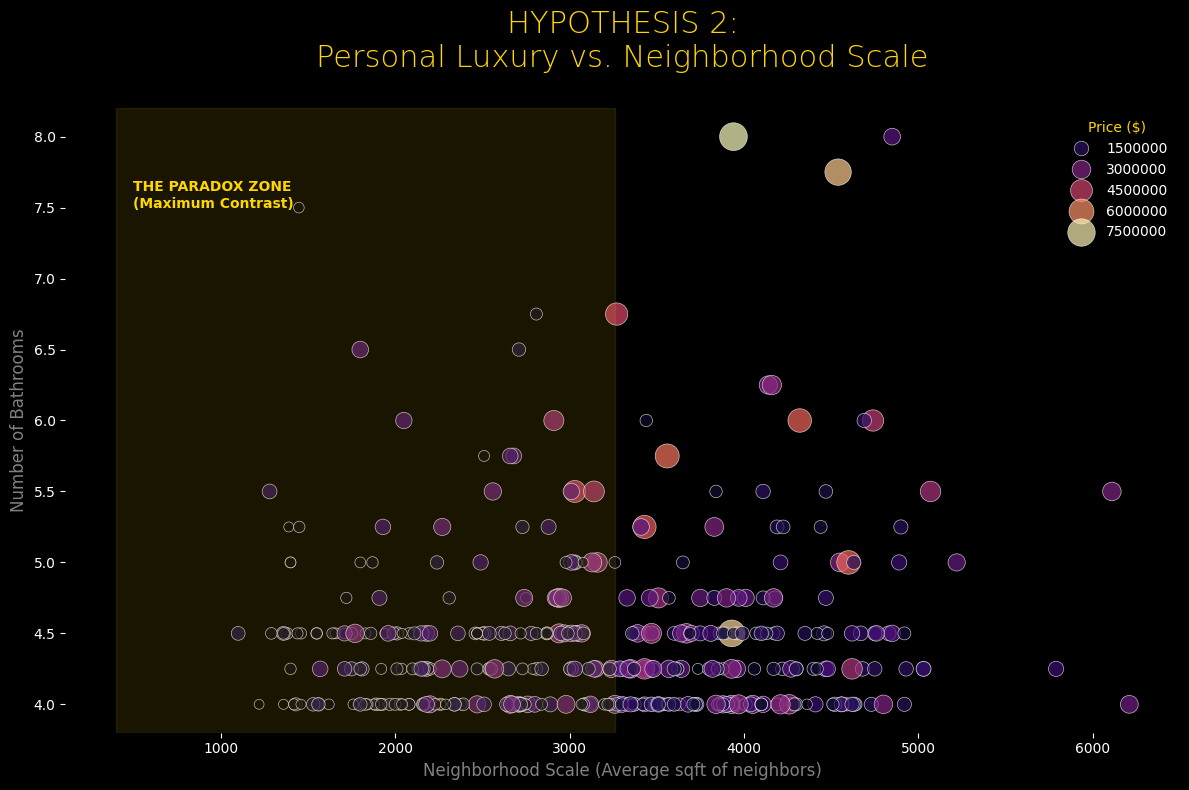

In [175]:
# 1. Dark Mode
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')
df=data.copy()
# 2. create scatter plot

# X: 15 (Neighborhood Scale)
# Y: n bathrooms (Personal Luxury)
scatter = sns.scatterplot(
    data=df[df['bathrooms'] >= 4], # bathrooms >= 4 als Filter für "Personal Luxury"
    x='sqft_living15', 
    y='bathrooms', 
    hue='price', 
    palette='magma', 
    size='price', 
    sizes=(50, 400), 
    alpha=0.7, 
    edgecolor='w', 
    linewidth=0.5, 
    ax=ax
)

# 3. title & labels
plt.title('HYPOTHESIS 2:\nPersonal Luxury vs. Neighborhood Scale', 
          fontsize=22, color='gold', fontweight='light', pad=30)

plt.xlabel('Neighborhood Scale (Average sqft of neighbors)', color='gray', fontsize=12)
plt.ylabel('Number of Bathrooms', color='gray', fontsize=12)

# 4. paradox zone
# many bathrooms + small neighbors = paradox zone (golden area of maximum contrast)
ax.axvspan(df['sqft_living15'].min(), df['sqft_living15'].quantile(0.947), 
           color='gold', alpha=0.1)
ax.text(df['sqft_living15'].min() + 100, df['bathrooms'].max() - 0.5, 
        'THE PARADOX ZONE\n(Maximum Contrast)', 
        color='gold', fontsize=10, fontweight='bold')

# 5. Legend & Clean-up
legend = ax.legend(title='Price ($)', loc='upper right', frameon=False, labelcolor='white')
plt.setp(legend.get_title(), color='gold')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

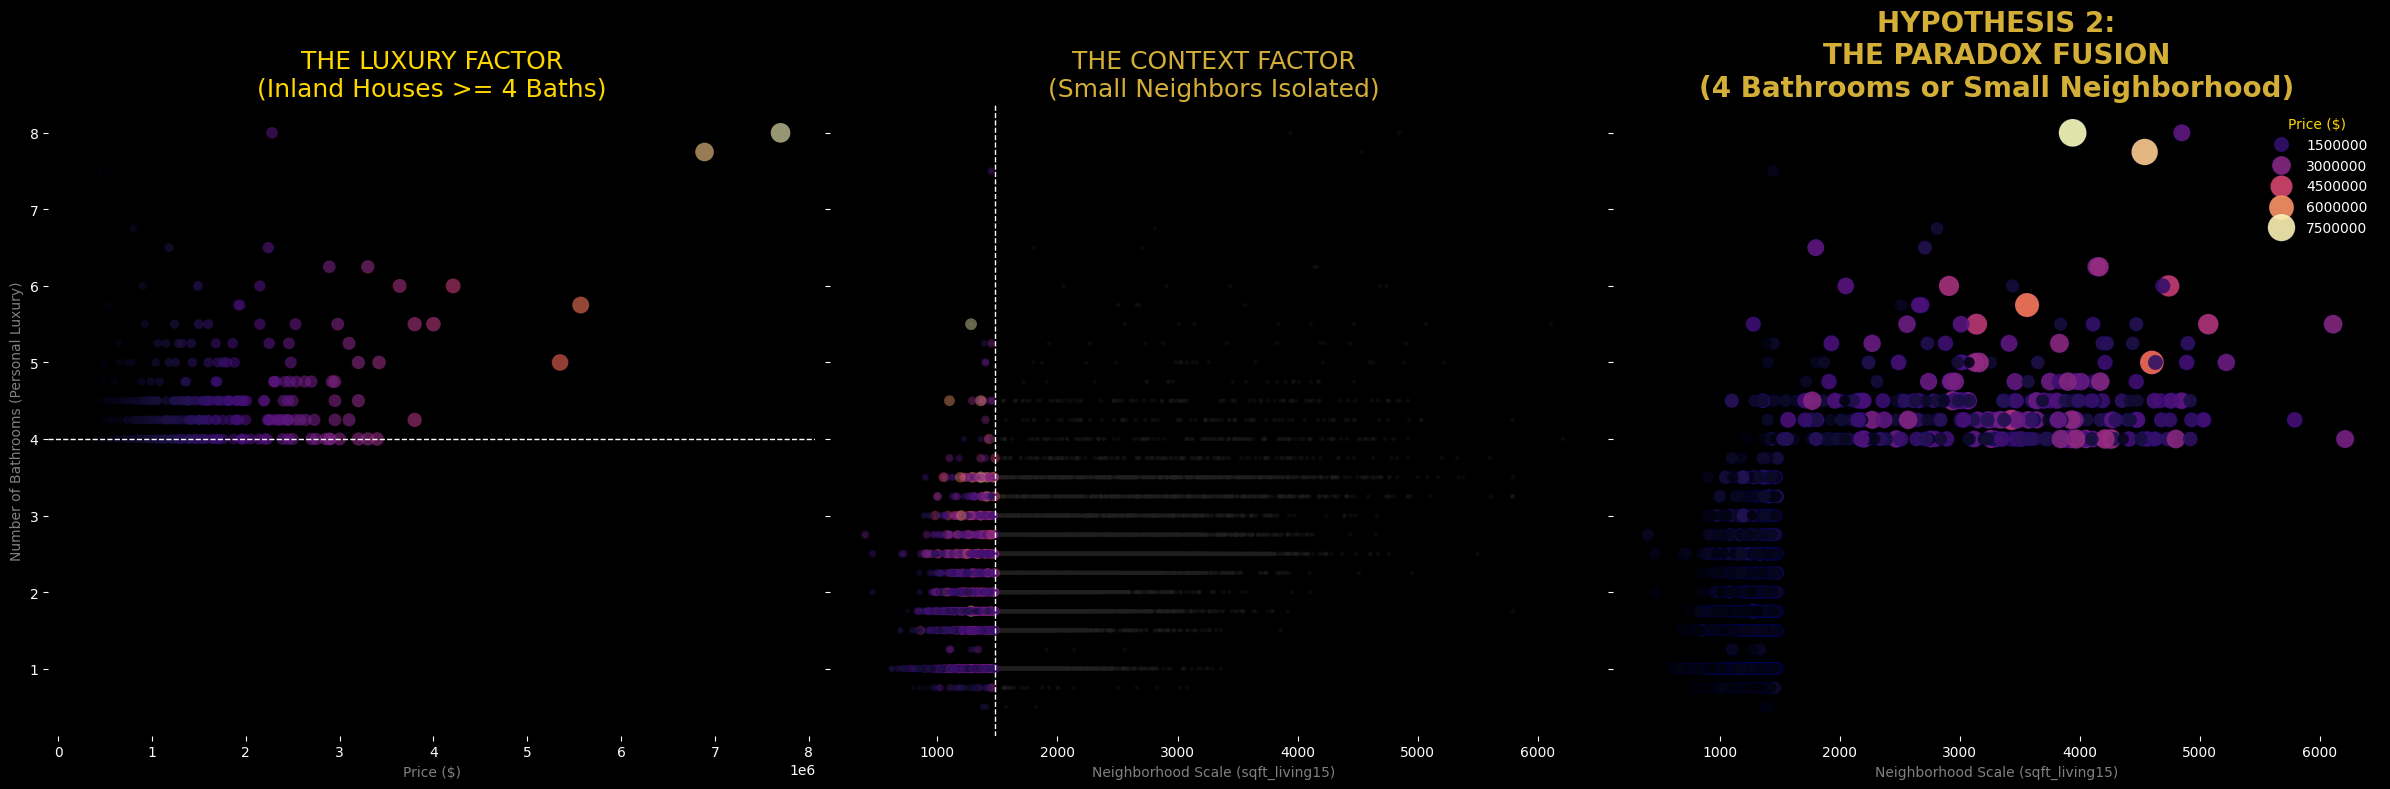

In [176]:

# --- 0. PREPARATION ---
# Create a base dataframe containing only inland properties to exclude waterfronts from the start
df_land = df[df['waterfront'] == 0].copy()

# Filter 1: High Bath Count (>= 4 Bathrooms) based on the inland subset
high_bath_land = df_land['bathrooms'] >= 4

# Filter 2: Small Neighborhood Scale (Bottom 25% of the inland market)
small_nb_threshold = df_land['sqft_living15'].quantile(0.25)
small_nb_filter = df_land['sqft_living15'] <= small_nb_threshold

# --- 1. SETUP THEME (Dark Mode) ---
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8), sharey=True) # Sharing Y-axis for scale consistency
fig.patch.set_facecolor('black')

# Common Y-axis label for all plots
y_label_text = 'Number of Bathrooms (Personal Luxury)'

# --- PLOT 1: THE LUXURY FACTOR ---
# Highlighting properties that meet the interior luxury requirement (>= 4 baths)
sns.scatterplot(
    data=df_land[high_bath_land], 
    x='price', 
    y='bathrooms', 
    hue='price', 
    palette='magma', 
    size='price', 
    sizes=(20, 200), 
    alpha=0.6, 
    ax=ax1, 
    edgecolor='none'
)
ax1.set_title('THE LUXURY FACTOR\n(Inland Houses >= 4 Baths)', color='gold', fontsize=18)
ax1.set_ylabel(y_label_text, color='gray')
ax1.set_xlabel('Price ($)', color='gray')
ax1.axhline(4, color='white', linestyle='--', linewidth=1) # Jacob's minimum luxury baseline

# --- PLOT 2: THE CONTEXT FACTOR ---
# Showing the entire inland market in the background
sns.scatterplot(
    data=df_land, 
    x='sqft_living15', 
    y='bathrooms', 
    color='#222222', 
    s=10, 
    alpha=0.3, 
    ax=ax2, 
    edgecolor='none'
)
# Overlaying properties in small neighborhoods (the potential "Pillars")
sns.scatterplot(
    data=df_land[small_nb_filter], 
    x='sqft_living15', 
    y='bathrooms', 
    hue='price', 
    palette='magma', 
    size='price',  
    s=15, 
    alpha=0.4, 
    ax=ax2, 
    edgecolor='none'
)
ax2.set_title('THE CONTEXT FACTOR\n(Small Neighbors Isolated)', color='#D4AF37', fontsize=18)
ax2.set_xlabel('Neighborhood Scale (sqft_living15)', color='gray')
ax2.axvline(small_nb_threshold, color='white', linestyle='--', linewidth=1) # Threshold for "Modest" context

# --- PLOT 3: THE PARADOX FUSION (OR-LOGIC) ---
# Combining both filters with a logical OR (|)
# Result: Properties that are either luxurious inside OR located in small neighborhoods
paradox_df = df_land[high_bath_land | small_nb_filter]

sns.scatterplot(
    data=paradox_df, 
    x='sqft_living15', 
    y='bathrooms', 
    hue='price', 
    palette='magma', 
    size='price', 
    sizes=(50, 400), 
    alpha=0.9, 
    ax=ax3, 
    edgecolor='darkblue', 
    linewidth=0.1
)
ax3.set_title('HYPOTHESIS 2:\nTHE PARADOX FUSION\n(4 Bathrooms or Small Neighborhood)', 
              color='#D4AF37', fontsize=20, fontweight='bold')
ax3.set_xlabel('Neighborhood Scale (sqft_living15)', color='gray')

# --- CLEANUP & STYLING ---
for ax in [ax1, ax2, ax3]:
    if ax.get_legend():
        ax.get_legend().remove()
    sns.despine(left=True, bottom=True)

# Adding a single clear legend for the final fusion plot
leg = ax3.legend(title='Price ($)', loc='upper right', frameon=False, labelcolor='white')
plt.setp(leg.get_title(), color='gold')

plt.tight_layout()
plt.show()

### 3 Hypothesis
-	box plot of different options
-   historic house but in great condition and not renovated(original)

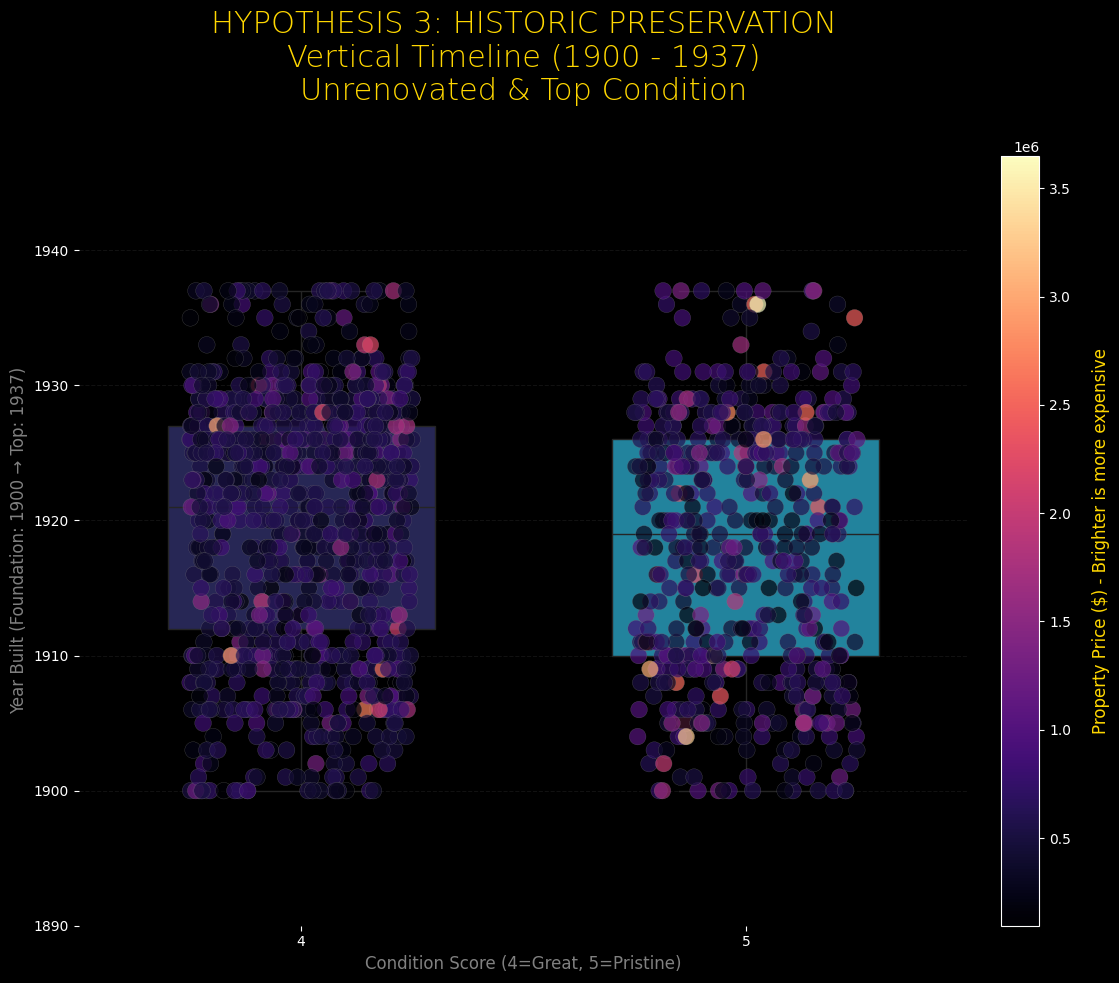

In [177]:


# --- 1. filter data ---
# Filter: old (1900-1937), not renovafted (==0), great condition (>=4)
vintage_selection = df[(df['yr_built'] >= 1900) & 
                       (df['yr_built'] <= 1937) & 
                       (df['is_renovated'] == 0) & 
                       (df['condition'] >= 4)].copy()

# --- 2. SETUP ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- 3. boxplot in background ---
sns.boxplot(
    data=vintage_selection, 
    x='condition', 
    y='yr_built',       
    hue='condition',      
    legend=False,         
    palette=["#1F1F5D", "#0D8FB2"], 
    showfliers=False,
    ax=ax,
    width=0.6
)

# --- 4. stripplot ---
# palette 'magma' dark tones = cheap, bright tones (yellow) = expensive
sns.stripplot(
    data=vintage_selection, 
    x='condition', 
    y='yr_built', 
    hue='price',        
    palette='magma',    
    size=12, 
    alpha=0.7, 
    jitter=0.25, 
    ax=ax,
    edgecolor='grey',
    linewidth=0.2,
    legend=False        
)

# --- 5. colorbar ---
norm = plt.Normalize(vintage_selection['price'].min(), vintage_selection['price'].max())
sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.03)
cbar.set_label('Property Price ($) - Brighter is more expensive', color='gold', size=12, labelpad=15)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

# --- 6. FINISHING ---
plt.title('HYPOTHESIS 3: HISTORIC PRESERVATION\nVertical Timeline (1900 - 1937)\nUnrenovated & Top Condition', 
          fontsize=22, color='gold', pad=40, fontweight='light')

plt.xlabel('Condition Score (4=Great, 5=Pristine)', color='gray', fontsize=12)
plt.ylabel('Year Built (Foundation: 1900 → Top: 1937)', color='gray', fontsize=12)

#fix Y-axis (don't invert to keep 1900 at the bottom)
ax.set_ylim(1890, 1947)

# label and gridlines for the time axis
ax.yaxis.grid(True, linestyle='--', which='major', color='#222222', alpha=0.5)

sns.despine(left=True, bottom=True)
plt.show()

In [178]:
#print((jacob_results).count()) #1061
#print((paradox_df).count()) #5728
#print((vintage_selection).count()) #1546

In [179]:
#connect the intersection of all 3 hypotheses
elite_intersection = df[
    df.index.isin(jacob_results.index) &
    df.index.isin(paradox_df.index) &
    df.index.isin(vintage_selection.index)
].copy()

# Sortieren nach Preis (aufsteigend), um die "Hidden Gems" zuerst zu sehen
elite_intersection = elite_intersection.sort_values(by='price', ascending=False)

print(f" 'H&A Unreal Estates' found juwels: {len(elite_intersection)}")
print("-" * 50)
print(elite_intersection[['price', 'sqft_lot', 'bathrooms', 'yr_built', 'condition', 'waterfront', 'sqft_living15']])

 'H&A Unreal Estates' found juwels: 23
--------------------------------------------------
          price  sqft_lot  bathrooms  yr_built  condition  waterfront  \
779   2250000.0    9453.0       4.25      1905          5         0.0   
943    915000.0    5589.0       2.50      1910          5         0.0   
783    715000.0    4800.0       1.00      1911          4         0.0   
32     687500.0    5000.0       1.75      1929          4         0.0   
1053   620000.0    5350.0       2.25      1929          4         0.0   
188    615000.0    2400.0       1.00      1901          4         0.0   
255    592500.0    9191.0       2.00      1928          5         0.0   
111    570000.0    3328.0       1.75      1905          5         0.0   
721    565000.0    4080.0       1.00      1911          5         0.0   
1004   563000.0    5000.0       2.00      1917          4         0.0   
308    550700.0    5000.0       1.00      1908          4         0.0   
249    481000.0    3000.0       1.

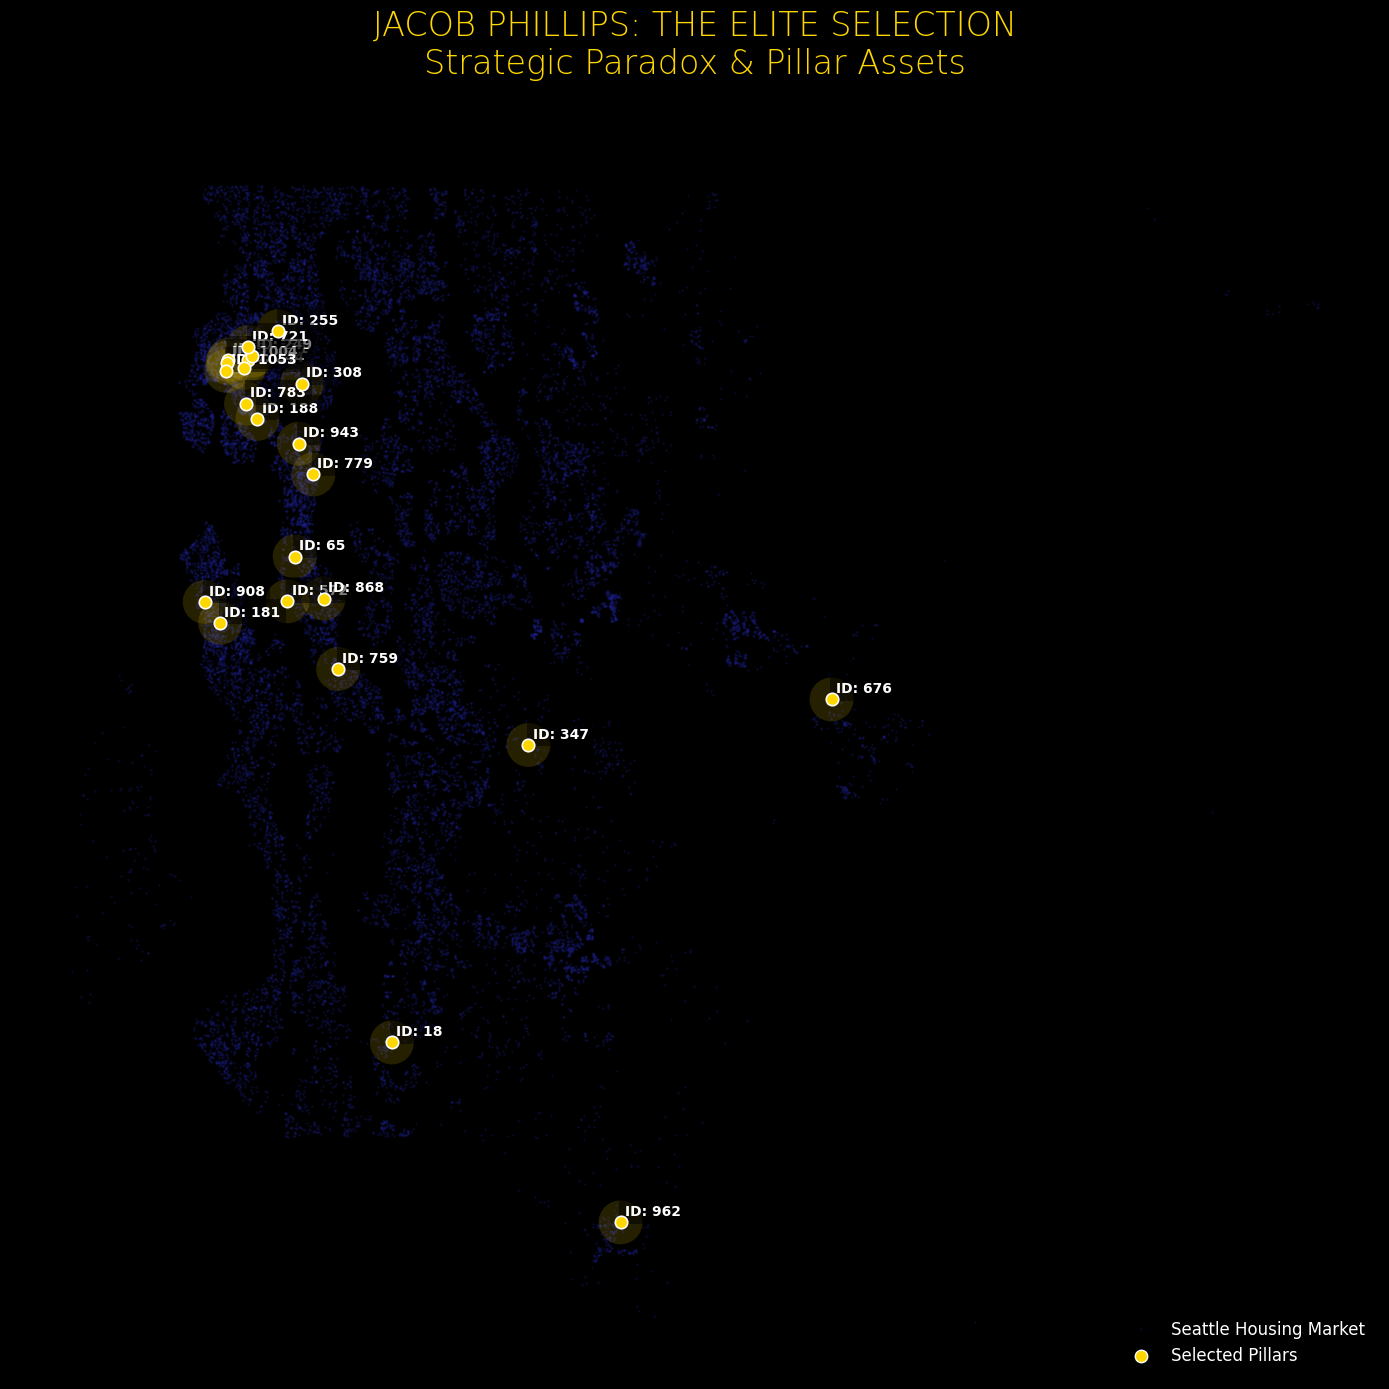

In [180]:

# --- 0. YOUR SELECTION ---
# Add as many IDs as you like to this list
pillar_id_list = elite_intersection.index.tolist() # Example with 4 IDs

# Extract data for all selected IDs at once
selected_pillars = df.loc[df.index.isin(pillar_id_list)]

# --- 1. SETUP THEME ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 14))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# 2. Market Background (Seattle / King County)
# Using your chosen deep blue "#1E228E" for the market dust
ax.scatter(df['long'], df['lat'], s=1, color="#1E228E", alpha=0.2, label='Seattle Housing Market')

# 3. Dynamic Plotting of the Selected IDs
# We iterate through the filtered dataframe
for idx, row in selected_pillars.iterrows():
    # Glow Effect (Outer halo)
    ax.scatter(row['long'], row['lat'], s=1000, color='gold', alpha=0.15, edgecolors='none')
    
    # The Pillar Point (Solid core)
    ax.scatter(row['long'], row['lat'], s=80, color='gold', edgecolor='white', 
               linewidth=1.2, zorder=5)
    
    # ID Labeling with slight offset for readability
    ax.text(row['long'] + 0.004, row['lat'] + 0.004, 
            f"ID: {idx}", color='white', fontsize=10, 
            fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

# --- 2. FINISHING & BRANDING ---
plt.title('JACOB PHILLIPS: THE ELITE SELECTION\nStrategic Paradox & Pillar Assets', 
          fontsize=24, color='gold', pad=40, fontweight='light')

# Legend (Proxy for the pillars)
ax.scatter([], [], color='gold', edgecolor='white', s=80, label='Selected Pillars')
plt.legend(loc='lower right', frameon=False, labelcolor='white', fontsize=12)

# Clean Look: Geography only
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [181]:


# --- 0. SCORING LOGIC (The "Triple Hypothesis" Rating) ---
# Ensure your IDs exist in the dataframe
plot_df = df.loc[df.index.isin(pillar_id_list)].copy()

# Helper function to normalize values between 0 and 1
def norm(series, reverse=False):
    if series.max() == series.min(): return 1.0
    if reverse:
        return (series.max() - series) / (series.max() - series.min())
    return (series - series.min()) / (series.max() - series.min())

# H1: Lot Size Score
s1 = norm(plot_df['sqft_lot'])
# H2: Paradox Score (High Bathrooms relative to small neighbors)
s2 = norm(plot_df['bathrooms'] / plot_df['sqft_living15'])
# H3: Vintage Score (Age + Condition)
s3 = norm(plot_df['condition'] + (1937 - plot_df['yr_built']))

# Calculate Final Pillar Score (0-100)
plot_df['pillar_score'] = ((s1 + s2 + s3) / 3 * 100).round(1)

# --- 1. DATA PREPARATION FOR HOVER ---
plot_df['Price_Display'] = plot_df['price'].map('${:,.0f}'.format)

# --- 2. CREATE INTERACTIVE MAP (NEW: scatter_map) ---
fig = px.scatter_map(
    plot_df,
    lat="lat",
    lon="long",
    color="pillar_score",         # Color by our Rating
    size="pillar_score",          # Size by our Rating
    size_max=25,                  
    hover_name=plot_df.index,
    hover_data={
        'lat': False, 
        'long': False, 
        'pillar_score': True,
        'Price_Display': True, 
        'yr_built': True,
        'condition': True
    },
    color_continuous_scale="Magma", # Deep luxury look
    zoom=10,
    height=800,
    title='<b>FOR JACOB PHILLIPS: STRATEGIC RANKING</b>'
)

# --- 3. STYLING (Dark Theme without Mapbox Token) ---
fig.update_layout(
    map_style="carto-darkmatter", # MapLibre dark style
    margin={"r":0,"t":100,"l":0,"b":0},
    paper_bgcolor="black",
    font_color="#D4AF37",
    title_font_size=26,
    coloraxis_colorbar=dict(title="Score")
)

fig.show()